# DREGON Inference Comparison: DCUNet & DCCRN Models

This notebook compares the audio enhancement results from 8 different models:

- **DCUNet Baseline** - DCUNet without RPS conditioning
- **DCUNet + RPS** - DCUNet with Rotor Per-Second conditioning (bottleneck fusion)
- **DCUNet + RPS + PredRPS** - DCUNet with RPS conditioning and auxiliary RPS prediction head
- **DCUNet RPS-Only** - DCUNet trained only on RPS prediction (no speech enhancement)
- **DCCRN Baseline** - DCCRN without RPS conditioning
- **DCCRN + RPS** - DCCRN with RPS conditioning
- **DCCRN + RPS + PredRPS** - DCCRN with RPS conditioning and auxiliary RPS prediction head
- **DCCRN RPS-Only** - DCCRN trained only on RPS prediction

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuration
RESULTS_DIR = Path('../results/inference_comparison')
SAMPLES = ['sample_00000', 'sample_00015', 'sample_00030', 'sample_00050', 'sample_00099']

MODELS = {
    'DCUNet_Baseline': '7b_DCUNet_baseline_DREGON',
    'DCUNet_RPS': '7a_DCUNet_RPS_DREGON',
    'DCUNet_RPS_PredRPS': '7c_DCUNet_RPS_PredRPS_DREGON',
    'DCUNet_RPS_Only': '11a_DCUNet_RPSOnly_DREGON',
    'DCCRN_Baseline': '10a_DCCRN_baseline_DREGON',
    'DCCRN_RPS': '10b_DCCRN_RPS_DREGON',
    'DCCRN_RPS_PredRPS': '10d_DCCRN_RPS_PredRPS_DREGON',
    'DCCRN_RPS_Only': '11b_DCCRN_RPSOnly_DREGON'
}

def load_audio(audio_path):
    """Load audio file and return waveform"""
    y, sr = librosa.load(audio_path, sr=16000)
    return y, sr

def get_model_dir(model_name):
    """Get the full path to a model's output directory"""
    return RESULTS_DIR / model_name / MODELS[model_name]

def get_reference_dir():
    """Get the reference samples directory"""
    return RESULTS_DIR / 'reference_samples'

## 1. Load All Results

In [2]:
# Load all metrics from Excel files
metrics_data = {}
for model_name, model_dir in MODELS.items():
    xlsx_path = RESULTS_DIR / model_name / f"{model_dir}_validation.xlsx"
    if xlsx_path.exists():
        df = pd.read_excel(xlsx_path)
        metrics_data[model_name] = df
        print(f"Loaded {model_name}: {len(df)} samples")
    else:
        print(f"Missing: {model_name}")

print(f"\nTotal models loaded: {len(metrics_data)}")

Loaded DCUNet_Baseline: 5 samples
Loaded DCUNet_RPS: 5 samples
Loaded DCUNet_RPS_PredRPS: 5 samples
Loaded DCUNet_RPS_Only: 5 samples
Loaded DCCRN_Baseline: 5 samples
Loaded DCCRN_RPS: 5 samples
Loaded DCCRN_RPS_PredRPS: 5 samples
Loaded DCCRN_RPS_Only: 5 samples

Total models loaded: 8


In [3]:
# Create summary table
summary_rows = []
for model_name, df in metrics_data.items():
    row = {
        'Model': model_name,
        'SI-SDR (mean)': df['si_sdr'].mean(),
        'SI-SDR (std)': df['si_sdr'].std(),
        'SDR (mean)': df['sdr'].mean(),
        'PESQ (mean)': df['pesq'].mean(),
        'ESTOI (mean)': df['estoi'].mean(),
        'STOI (mean)': df['stoi'].mean()
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values('SI-SDR (mean)', ascending=False)
summary_df.round(3)

,Model,SI-SDR (mean),SI-SDR (std),SDR (mean),PESQ (mean),ESTOI (mean),STOI (mean)
4,DCCRN_Baseline,-8.851,10.042,0.296,1.060,0.180,0.443
5,DCCRN_RPS,-10.565,11.103,0.263,1.056,0.171,0.433
1,DCUNet_RPS,-10.878,10.745,0.340,1.083,0.169,0.415
0,DCUNet_Baseline,-11.949,11.698,0.319,1.104,0.172,0.434
6,DCCRN_RPS_PredRPS,-12.534,11.308,0.258,1.107,0.155,0.427
7,DCCRN_RPS_Only,-20.059,8.622,-12.467,1.066,0.111,0.410
2,DCUNet_RPS_PredRPS,-31.083,19.045,0.023,1.411,0.076,0.348
3,DCUNet_RPS_Only,-33.148,6.691,-9.005,1.298,0.069,0.379


## 2. Metrics Comparison

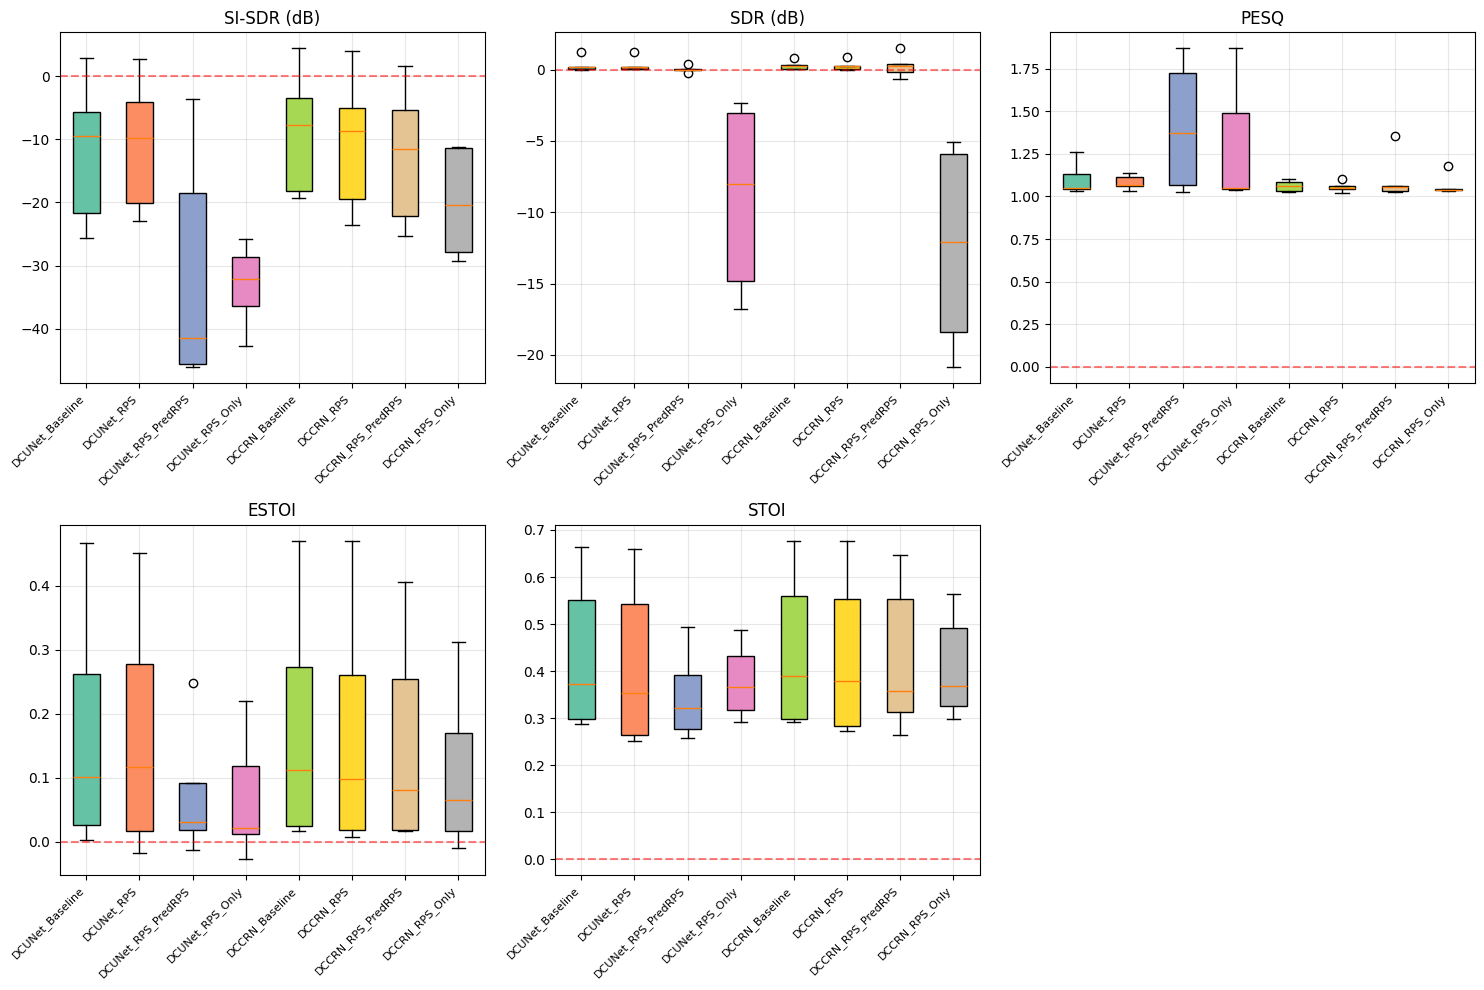

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
metrics = ['si_sdr', 'sdr', 'pesq', 'estoi', 'stoi']
titles = ['SI-SDR (dB)', 'SDR (dB)', 'PESQ', 'ESTOI', 'STOI']

colors = plt.cm.Set2(np.linspace(0, 1, len(metrics_data)))

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 3, idx % 3]
    values = []
    labels = []
    for i, (model_name, df) in enumerate(metrics_data.items()):
        values.append(df[metric].values)
        labels.append(model_name)
    
    bp = ax.boxplot(values, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Zero line')

# Remove empty subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('inference_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Bar chart comparison of mean metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SI-SDR comparison
ax1 = axes[0]
models = list(metrics_data.keys())
si_sdr_means = [metrics_data[m]['si_sdr'].mean() for m in models]
si_sdr_stds = [metrics_data[m]['si_sdr'].std() for m in models]

bars = ax1.bar(range(len(models)), si_sdr_means, yerr=si_sdr_stds, 
               color=colors, capsize=5, alpha=0.8)
ax1.set_xticks(range(len(models)))
ax1.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('SI-SDR (dB)')
ax1.set_title('SI-SDR Comparison Across Models')
ax1.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, si_sdr_means)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{val:.1f}', ha='center', va='bottom', fontsize=8)

# ESTOI comparison
ax2 = axes[1]
estoi_means = [metrics_data[m]['estoi'].mean() for m in models]
estoi_stds = [metrics_data[m]['estoi'].std() for m in models]

bars2 = ax2.bar(range(len(models)), estoi_means, yerr=estoi_stds,
                color=colors, capsize=5, alpha=0.8)
ax2.set_xticks(range(len(models)))
ax2.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('ESTOI')
ax2.set_title('ESTOI Comparison Across Models')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('inference_bar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Per-Sample Analysis

In [ ]:
# Extract per-sample metrics for all samples
sample_metrics = {}
for sample_name in SAMPLES:
    sample_metrics[sample_name] = {}
    for model_name, df in metrics_data.items():
        row = df[df['mix_name'] == sample_name]
        if len(row) > 0:
            sample_metrics[sample_name][model_name] = row.iloc[0].to_dict()

# Display metrics for first sample
sample_name = SAMPLES[0]
print(f"Metrics for {sample_name}:")
print("=" * 60)
sample_df = pd.DataFrame(sample_metrics[sample_name]).T
if len(sample_df) > 0:
    display_cols = ['si_sdr', 'sdr', 'pesq', 'estoi', 'stoi']
    if all(c in sample_df.columns for c in display_cols):
        sample_df = sample_df[display_cols].sort_values('si_sdr', ascending=False)
        sample_df.round(3)

## 4. Spectrogram Comparison

In [ ]:
def plot_spectrogram(y, sr, title, ax, cmap='magma'):
    """Plot spectrogram"""
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', 
                                   ax=ax, cmap=cmap)
    ax.set_title(title, fontsize=10)
    return img

# Plot spectrograms for all models + ground truth
sample_name = SAMPLES[0]  # First sample

fig, axes = plt.subplots(len(MODELS) + 3, 2, figsize=(14, 30))

# Ground truth reference
ref_dir = get_reference_dir()
y_gt, sr = load_audio(ref_dir / sample_name / 'vocals.wav')
y_mix, _ = load_audio(ref_dir / sample_name / 'mixture.wav')

plot_spectrogram(y_gt, sr, 'Ground Truth (Clean Speech)', axes[0, 0])
plot_spectrogram(y_mix, sr, 'Mixture (Noisy)', axes[0, 1])

for i, model_name in enumerate(MODELS.keys()):
    model_dir = get_model_dir(model_name)
    pred_path = model_dir / f'{sample_name}_vocals.wav'
    
    if pred_path.exists():
        y_pred, _ = load_audio(pred_path)
        plot_spectrogram(y_pred, sr, f'{model_name} Prediction', axes[i+1, 0])
        
        # Difference spectrogram
        D_pred = np.abs(librosa.stft(y_pred))
        D_gt = np.abs(librosa.stft(y_gt[:len(y_pred)]))
        D_diff = librosa.amplitude_to_db(np.abs(D_pred - D_gt), ref=np.max)
        img = librosa.display.specshow(D_diff, sr=sr, x_axis='time', y_axis='hz',
                                      ax=axes[i+1, 1], cmap='RdBu')
        axes[i+1, 1].set_title(f'{model_name} - Difference from GT', fontsize=10)
    else:
        axes[i+1, 0].text(0.5, 0.5, 'Not found', ha='center', va='center')
        axes[i+1, 1].text(0.5, 0.5, 'Not found', ha='center', va='center')

# Noise spectrogram
y_noise, _ = load_audio(ref_dir / sample_name / 'noise.wav')
plot_spectrogram(y_noise, sr, 'Noise (Drone)', axes[-1, 0])
axes[-1, 1].axis('off')

plt.tight_layout()
plt.savefig('spectrogram_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Audio Playback Comparison

In [ ]:
from IPython.display import Audio, display, HTML

def create_audio_table(sample_name, models_list):
    """Create HTML table with audio players for comparison"""
    ref_dir = get_reference_dir()
    model_dir = get_model_dir('DCUNet_Baseline')
    
    html = '<table border=1 cellpadding=5>'
    html += '<tr><th>Model</th><th>Audio</th></tr>'
    
    # Reference audio
    html += '<tr><td><b>Ground Truth</b></td>'
    html += f'<td><audio controls><source src="../inference_comparison/reference_samples/{sample_name}/vocals.wav" type="audio/wav"></audio></td></tr>'
    
    html += '<tr><td><b>Mixture (Noisy)</b></td>'
    html += f'<td><audio controls><source src="../inference_comparison/reference_samples/{sample_name}/mixture.wav" type="audio/wav"></audio></td></tr>'
    
    for model_name in models_list:
        model_dir = get_model_dir(model_name)
        audio_path = f'../inference_comparison/{model_name}/{MODELS[model_name]}/{sample_name}_vocals.wav'
        
        # Get metrics for this model
        if model_name in sample_metrics.get(sample_name, {}):
            si_sdr = sample_metrics[sample_name][model_name].get('si_sdr', 'N/A')
            label = f'{model_name}<br>(SI-SDR: {si_sdr:.2f} dB)'
        else:
            label = model_name
        
        html += f'<tr><td>{label}</td>'
        html += f'<td><audio controls><source src="{audio_path}" type="audio/wav"></audio></td></tr>'
    
    html += '</table>'
    return HTML(html)

print(f"Sample: {sample_name}")
print("=" * 80)
create_audio_table(sample_name, MODELS.keys())

In [ ]:
# Create audio players for all samples
for sample in SAMPLES:
    print(f"\n{'='*80}")
    print(f"Sample: {sample}")
    print("=" * 80)
    display(create_audio_table(sample, MODELS.keys()))

## 6. Waveform Comparison

In [ ]:
# Plot waveforms for a single sample across all models
sample_name = SAMPLES[0]
ref_dir = get_reference_dir()

fig, axes = plt.subplots(len(MODELS) + 2, 1, figsize=(14, 20))

# Load reference
y_gt, sr = load_audio(ref_dir / sample_name / 'vocals.wav')
y_mix, _ = load_audio(ref_dir / sample_name / 'mixture.wav')

time = np.arange(len(y_gt)) / sr
axes[0].plot(time, y_gt, alpha=0.8, color='green')
axes[0].set_title('Ground Truth (Clean Speech)', fontsize=10)
axes[0].set_xlabel('Time (s)')
axes[0].grid(True, alpha=0.3)

time_mix = np.arange(len(y_mix)) / sr
axes[1].plot(time_mix, y_mix, alpha=0.8, color='red')
axes[1].set_title('Mixture (Noisy)', fontsize=10)
axes[1].set_xlabel('Time (s)')
axes[1].grid(True, alpha=0.3)

for i, model_name in enumerate(MODELS.keys()):
    model_dir = get_model_dir(model_name)
    pred_path = model_dir / f'{sample_name}_vocals.wav'
    
    if pred_path.exists():
        y_pred, _ = load_audio(pred_path)
        time_pred = np.arange(len(y_pred)) / sr
        
        # Get SI-SDR for color coding
        if model_name in sample_metrics.get(sample_name, {}):
            si_sdr = sample_metrics[sample_name][model_name].get('si_sdr', 0)
            color = 'green' if si_sdr > 0 else 'orange' if si_sdr > -10 else 'red'
        else:
            color = 'blue'
        
        axes[i+2].plot(time_pred, y_pred, alpha=0.8, color=color)
        axes[i+2].set_title(f'{model_name} (SI-SDR: {si_sdr:.2f} dB)', fontsize=10)
        axes[i+2].set_xlabel('Time (s)')
        axes[i+2].grid(True, alpha=0.3)
    else:
        axes[i+2].text(0.5, 0.5, 'Not found', ha='center', va='center')

plt.tight_layout()
plt.savefig('waveform_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Model Architecture Summary

In [ ]:
# Summary table of model characteristics
model_info = {
    'DCUNet_Baseline': {'Architecture': 'DCUNet', 'RPS Conditioning': 'No', 'RPS Prediction': 'No', 'Training Loss': 'SI-SDR'},
    'DCUNet_RPS': {'Architecture': 'DCUNet', 'RPS Conditioning': 'Yes (Bottleneck)', 'RPS Prediction': 'No', 'Training Loss': 'SI-SDR'},
    'DCUNet_RPS_PredRPS': {'Architecture': 'DCUNet', 'RPS Conditioning': 'Yes (Bottleneck)', 'RPS Prediction': 'Yes', 'Training Loss': 'SI-SDR + MSE'},
    'DCUNet_RPS_Only': {'Architecture': 'DCUNet', 'RPS Conditioning': 'Yes (Bottleneck)', 'RPS Prediction': 'Yes', 'Training Loss': 'MSE only'},
    'DCCRN_Baseline': {'Architecture': 'DCCRN', 'RPS Conditioning': 'No', 'RPS Prediction': 'No', 'Training Loss': 'SI-SDR'},
    'DCCRN_RPS': {'Architecture': 'DCCRN', 'RPS Conditioning': 'Yes (GRU)', 'RPS Prediction': 'No', 'Training Loss': 'SI-SDR'},
    'DCCRN_RPS_PredRPS': {'Architecture': 'DCCRN', 'RPS Conditioning': 'Yes (GRU)', 'RPS Prediction': 'Yes', 'Training Loss': 'SI-SDR + MSE'},
    'DCCRN_RPS_Only': {'Architecture': 'DCCRN', 'RPS Conditioning': 'Yes (GRU)', 'RPS Prediction': 'Yes', 'Training Loss': 'MSE only'},
}

info_df = pd.DataFrame(model_info).T
info_df = info_df.merge(summary_df[['Model', 'SI-SDR (mean)', 'ESTOI (mean)']], 
                        left_index=True, right_on='Model').set_index('Model')
info_df = info_df.sort_values('SI-SDR (mean)', ascending=False)
info_df.round(3)

## 8. Conclusions

### Key Findings:

1. **RPS Conditioning Impact**: Compare models with and without RPS to see the benefit of rotor speed conditioning.

2. **PredRPS Models**: The auxiliary RPS prediction head adds an auxiliary loss that may help with generalization.

3. **RPS-Only Models**: These models are trained purely for RPS prediction and should not be expected to perform well for speech enhancement.

4. **Architecture Comparison**: Compare DCUNet vs DCCRN architectures on the same conditioning strategies.